In this file we tested how the Artificial Neural Network is able to predict the energy consumption in national holidays (weekdays) correctly.
The first run feeds 2 months of data that has no national holidays to the ANN and makes a prediction on a national holiday (Sep 5 - Labor day)
The second run feeds the same 2 months of data with the national holiday to the ANN and makes a prediction a random national holiday.
We wanted to see how different the model predicts when it has national holiday in the dataset
 

In [1]:
import pandas as pd 
import numpy as np

from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler

from keras.models import Sequential
from keras.layers import Dense
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

import ipympl 
%matplotlib ipympl



file_path = '../Dataset/preprocessed_combined_data_weekday_3-2022_3-2023.csv'

df = pd.read_csv(file_path)

df.set_index('Date Time', inplace=True)

display(df)

,kW,Nantum,Season,Altimeter reading,DP Temp (F),DB Temp (F),Heat_day,Cool_day,DP_12h,DB_12h,DP_24h,DB_24h,Weekday_0,Weekday_1,Weekday_2,Weekday_3,Weekday_4,Weekday_5,Weekday_6
Date Time,,,,,,,,,,,,,,,,,,,
2022-03-24 00:00:00,121.500,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,1,0,0,0
2022-03-24 00:15:00,121.500,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,1,0,0,0
2022-03-24 00:30:00,119.248,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,1,0,0,0
2022-03-24 00:45:00,120.600,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,1,0,0,0
2022-03-24 01:00:00,123.300,0,0,30.11,16.0,56,0.093750,0.000000,12.0,74.0,23.0,58.0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-22 22:45:00,117.448,1,0,30.03,34.0,49,0.166667,0.000000,26.0,57.0,38.0,46.0,0,0,1,0,0,0,0
2023-03-22 23:00:00,115.200,1,0,30.03,34.0,50,0.156250,0.000000,24.0,57.0,38.0,45.0,0,0,1,0,0,0,0
2023-03-22 23:15:00,118.348,1,0,30.03,34.0,50,0.156250,0.000000,24.0,57.0,38.0,45.0,0,0,1,0,0,0,0


In [2]:
df.index = pd.to_datetime(df.index)

mask = (df.index.month > 5) & (df.index.month < 7) 

df_june = df[mask]

display(df_june)

,kW,Nantum,Season,Altimeter reading,DP Temp (F),DB Temp (F),Heat_day,Cool_day,DP_12h,DB_12h,DP_24h,DB_24h,Weekday_0,Weekday_1,Weekday_2,Weekday_3,Weekday_4,Weekday_5,Weekday_6
Date Time,,,,,,,,,,,,,,,,,,,
2022-06-01 00:00:00,109.800,1,1,29.93,28.0,74,0.0,0.177083,25.0,81.0,24.0,69.0,0,0,1,0,0,0,0
2022-06-01 00:15:00,110.248,1,1,29.93,28.0,74,0.0,0.177083,25.0,81.0,24.0,69.0,0,0,1,0,0,0,0
2022-06-01 00:30:00,110.248,1,1,29.93,28.0,74,0.0,0.177083,25.0,81.0,24.0,69.0,0,0,1,0,0,0,0
2022-06-01 00:45:00,109.348,1,1,29.93,28.0,74,0.0,0.177083,25.0,81.0,24.0,69.0,0,0,1,0,0,0,0
2022-06-01 01:00:00,110.700,1,1,29.95,27.0,72,0.0,0.156250,25.0,84.0,19.0,67.0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-06-30 22:45:00,121.500,0,1,29.87,37.0,90,0.0,0.343750,42.0,99.0,40.0,93.0,0,0,0,1,0,0,0
2022-06-30 23:00:00,118.800,0,1,29.87,36.0,90,0.0,0.343750,42.0,101.0,40.0,93.0,0,0,0,1,0,0,0
2022-06-30 23:15:00,116.552,0,1,29.87,36.0,90,0.0,0.343750,42.0,101.0,40.0,93.0,0,0,0,1,0,0,0


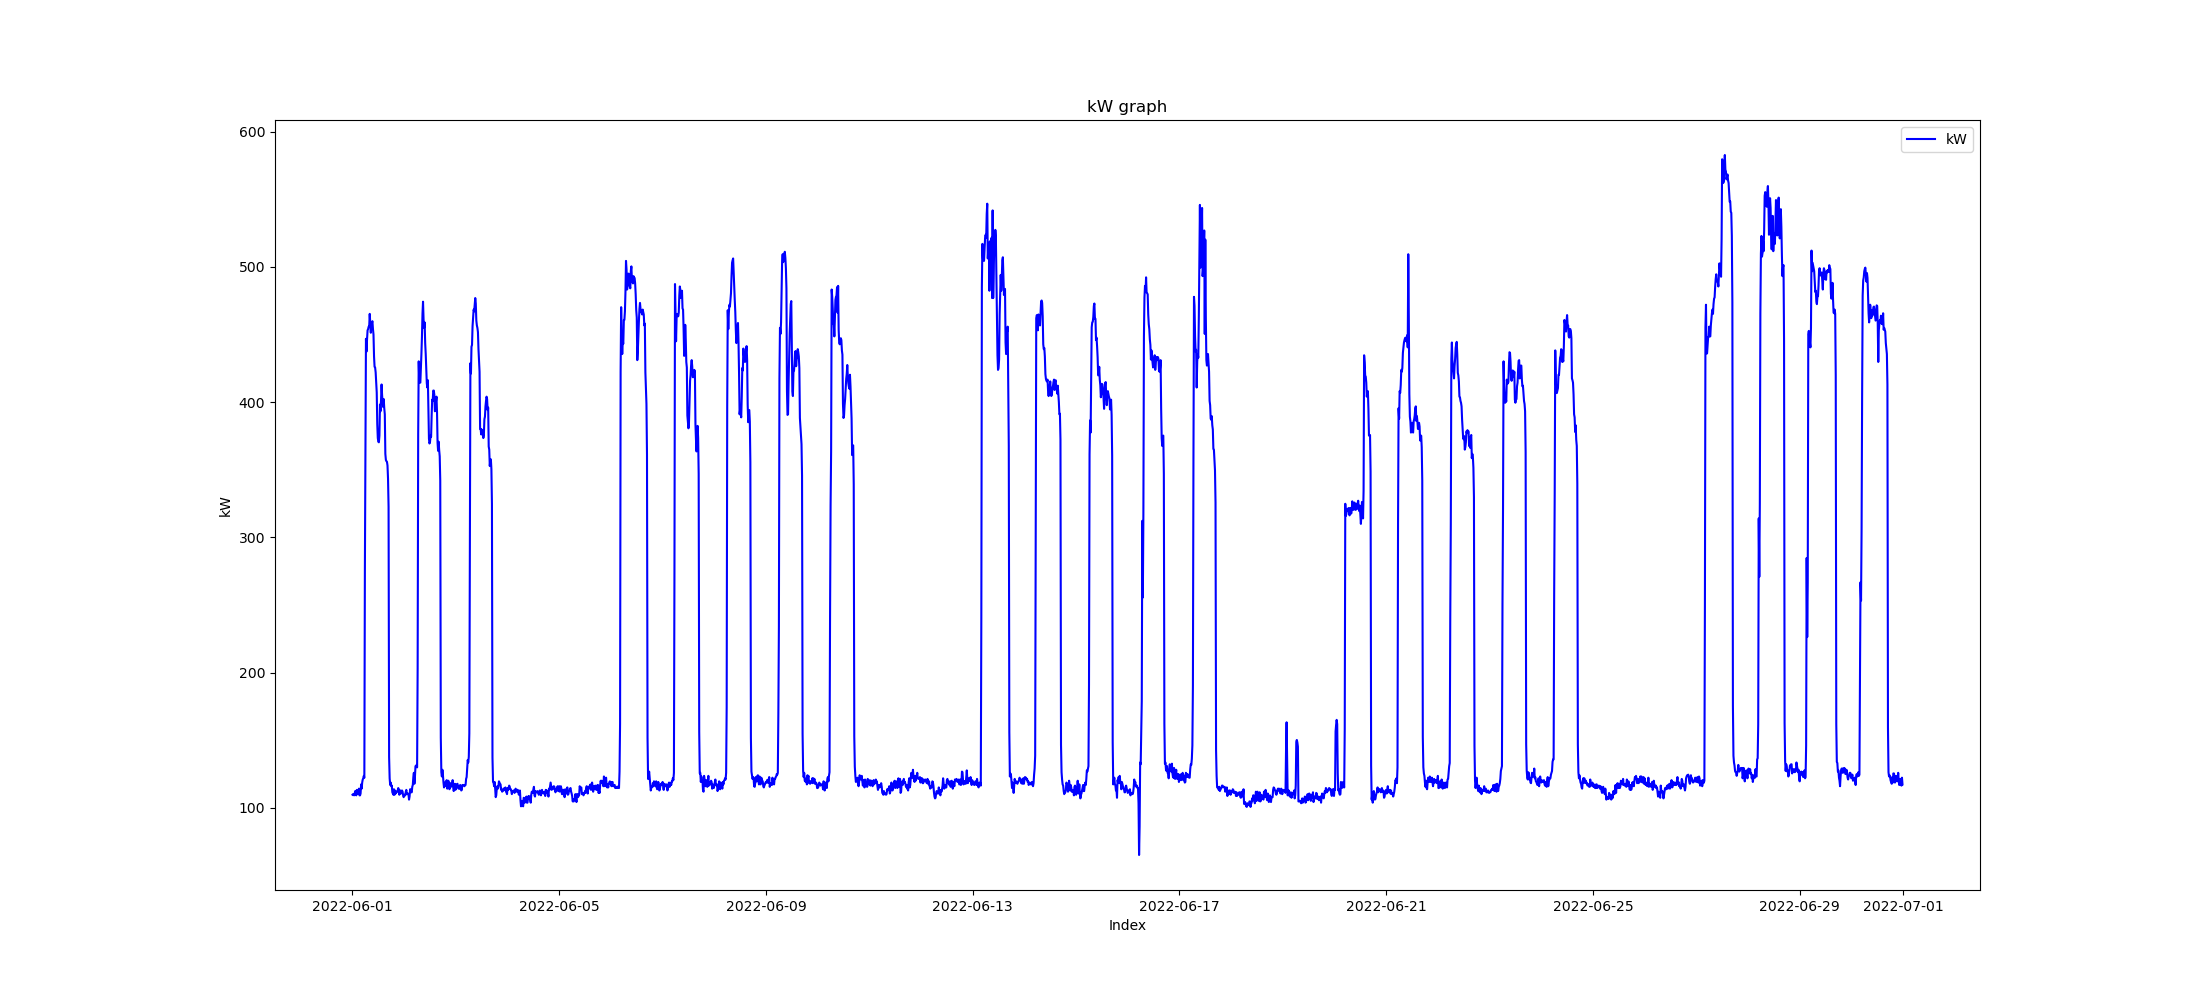

In [3]:

plt.figure(figsize=(22,10))

plt.plot(df_june["kW"], label="kW", color="blue")

# Adding labels and title
plt.xlabel("Index")
plt.ylabel("kW")
plt.title("kW graph")

# Adding legend
plt.legend()

# Displaying the plot
plt.show()

In [4]:
mask2 = (df.index.month > 6) & (df.index.month < 10) # March April May

df_july_aug = df[mask2]

display(df_july_aug)

,kW,Nantum,Season,Altimeter reading,DP Temp (F),DB Temp (F),Heat_day,Cool_day,DP_12h,DB_12h,DP_24h,DB_24h,Weekday_0,Weekday_1,Weekday_2,Weekday_3,Weekday_4,Weekday_5,Weekday_6
Date Time,,,,,,,,,,,,,,,,,,,
2022-07-01 00:00:00,126.000,0,1,29.88,35.0,89,0.0,0.333333,41.0,102.0,39.0,91.0,0,0,0,0,1,0,0
2022-07-01 00:15:00,142.200,0,1,29.88,35.0,89,0.0,0.333333,41.0,102.0,39.0,91.0,0,0,0,0,1,0,0
2022-07-01 00:30:00,121.500,0,1,29.88,35.0,89,0.0,0.333333,41.0,102.0,39.0,91.0,0,0,0,0,1,0,0
2022-07-01 00:45:00,120.152,0,1,29.88,35.0,89,0.0,0.333333,41.0,102.0,39.0,91.0,0,0,0,0,1,0,0
2022-07-01 01:00:00,119.248,0,1,29.88,37.0,88,0.0,0.322917,40.0,103.0,39.0,90.0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-09-30 22:45:00,106.652,1,1,29.79,33.0,80,0.0,0.239583,32.0,92.0,52.0,83.0,0,0,0,0,1,0,0
2022-09-30 23:00:00,105.300,1,1,29.78,35.0,78,0.0,0.218750,34.0,94.0,53.0,83.0,0,0,0,0,1,0,0
2022-09-30 23:15:00,110.700,1,1,29.78,35.0,78,0.0,0.218750,34.0,94.0,53.0,83.0,0,0,0,0,1,0,0


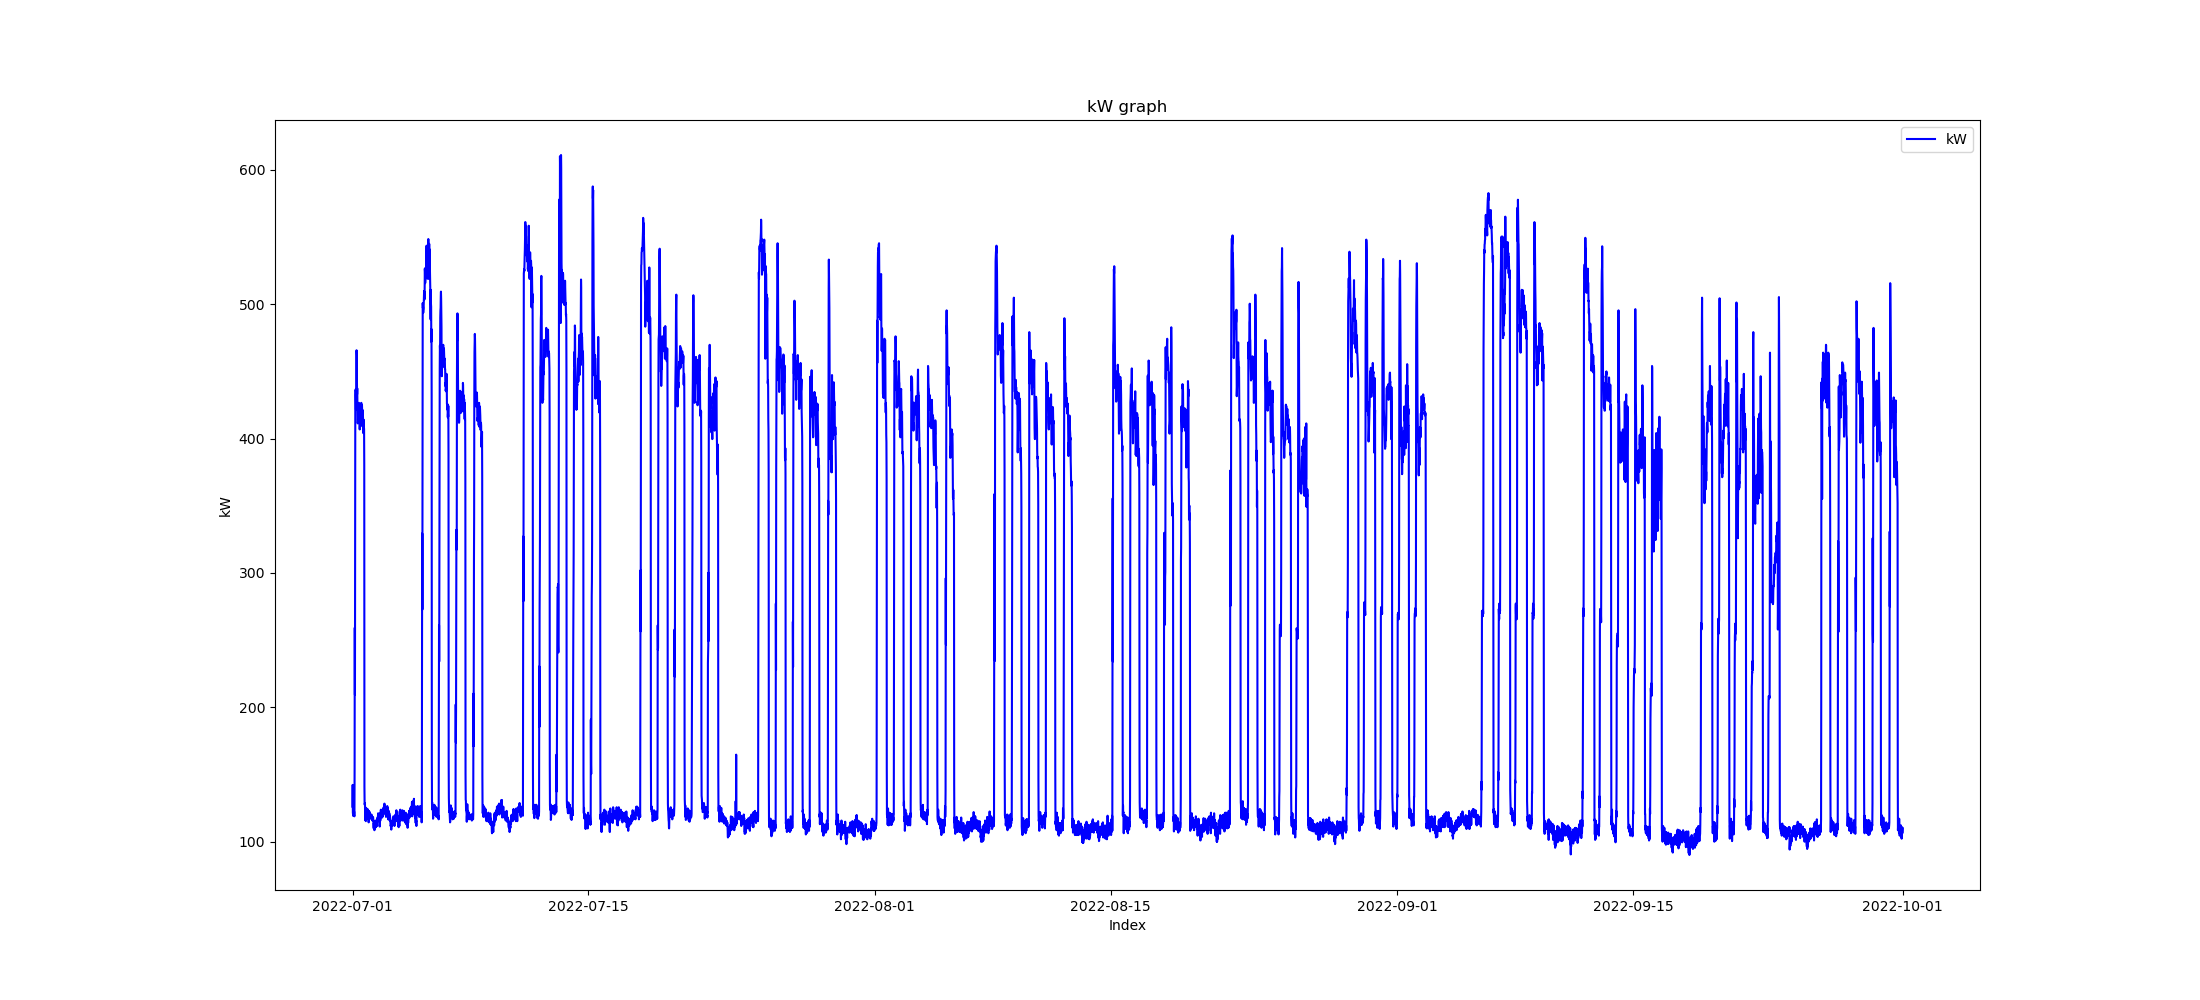

In [5]:

plt.figure(figsize=(22,10))

plt.plot(df_july_aug["kW"], label="kW", color="blue")

# Adding labels and title
plt.xlabel("Index")
plt.ylabel("kW")
plt.title("kW graph")

# Adding legend
plt.legend()

# Displaying the plot
plt.show()

In [6]:
start_date = '2022-07-05'
end_date = '2022-09-04'

date_range_df = df_july_aug.loc[start_date:end_date]

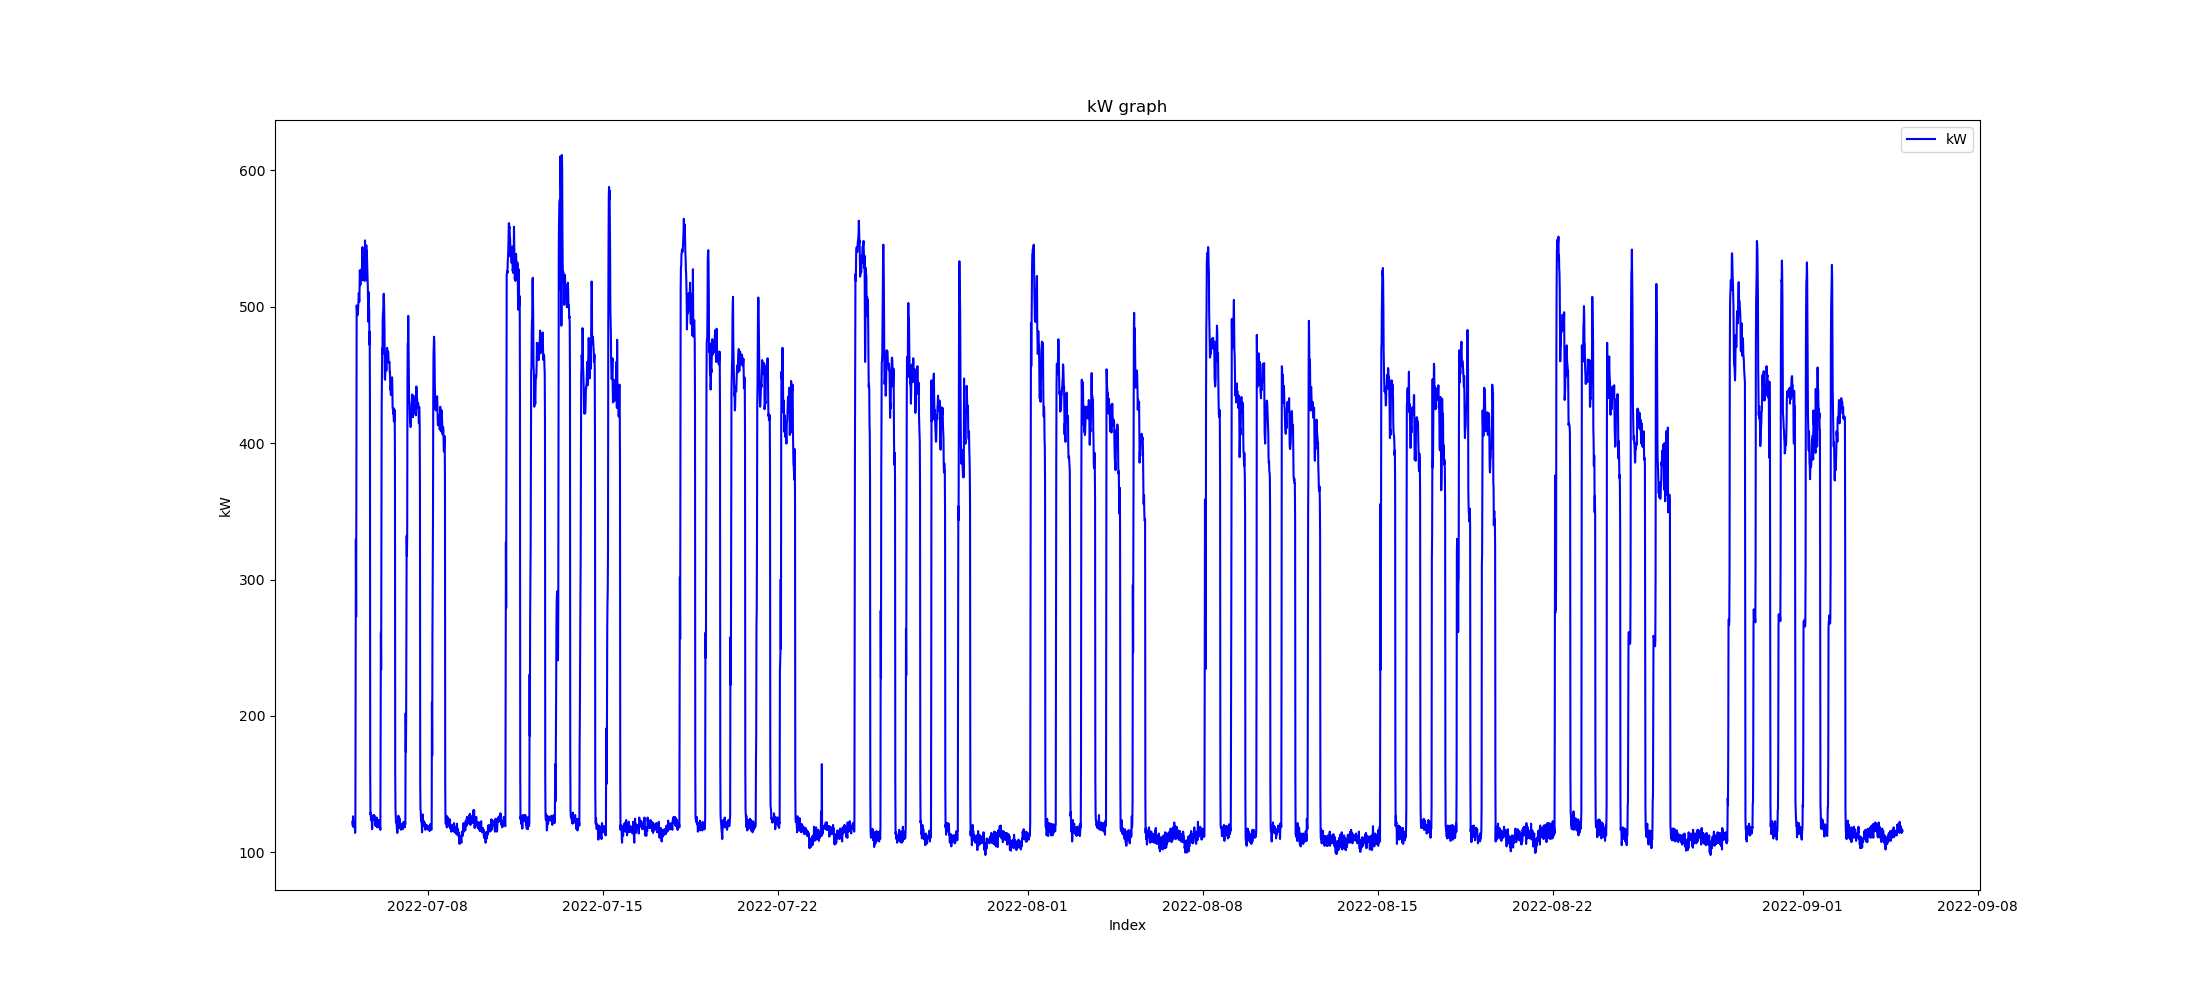

In [7]:
plt.figure(figsize=(22,10))

plt.plot(date_range_df["kW"], label="kW", color="blue")

# Adding labels and title
plt.xlabel("Index")
plt.ylabel("kW")
plt.title("kW graph")

# Adding legend
plt.legend()

# Displaying the plot
plt.show()

In [8]:
display(date_range_df)

,kW,Nantum,Season,Altimeter reading,DP Temp (F),DB Temp (F),Heat_day,Cool_day,DP_12h,DB_12h,DP_24h,DB_24h,Weekday_0,Weekday_1,Weekday_2,Weekday_3,Weekday_4,Weekday_5,Weekday_6
Date Time,,,,,,,,,,,,,,,,,,,
2022-07-05 00:00:00,122.400,0,1,29.85,26.0,83,0.0,0.270833,23.0,97.0,33.0,82.0,0,1,0,0,0,0,0
2022-07-05 00:15:00,119.700,0,1,29.85,26.0,83,0.0,0.270833,23.0,97.0,33.0,82.0,0,1,0,0,0,0,0
2022-07-05 00:30:00,126.448,0,1,29.85,26.0,83,0.0,0.270833,23.0,97.0,33.0,82.0,0,1,0,0,0,0,0
2022-07-05 00:45:00,118.800,0,1,29.85,26.0,83,0.0,0.270833,23.0,97.0,33.0,82.0,0,1,0,0,0,0,0
2022-07-05 01:00:00,120.600,0,1,29.85,30.0,81,0.0,0.250000,21.0,99.0,34.0,81.0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-09-04 22:45:00,115.200,0,1,29.85,49.0,94,0.0,0.385417,52.0,101.0,52.0,95.0,0,0,0,0,0,0,1
2022-09-04 23:00:00,114.300,0,1,29.86,49.0,92,0.0,0.364583,54.0,103.0,53.0,93.0,0,0,0,0,0,0,1
2022-09-04 23:15:00,117.000,0,1,29.86,49.0,92,0.0,0.364583,54.0,103.0,53.0,93.0,0,0,0,0,0,0,1


Data is ready. Feed it to the neural neutwork

In [9]:
X = date_range_df.drop('kW', axis = 1)
y = date_range_df.kW

#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

# Split data into training and temporary data (80% training, 20% temporary)
# X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)

# Split temporary data into testing and validation sets (50% testing, 50% validation)
# X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)


#Standardize features by removing the mean and scaling to unit variance
scaler=StandardScaler()
scaler.fit(X)

X_scaled = scaler.transform(X)

# X_val_scaled = scaler.transform(X_val)
# X_test_scaled = scaler.transform(X_test)

In [10]:
epoch = 500

# define the model
# Experiment with deeper and wider networks

# Sequential constructor automatically/implicitly creates an input layer when the first layer is added to the model. Its shape is determined by the "input_dim" parameter of the first layer
model = Sequential()

# Dense layers (all connected) are added to the neural network with the specified neuron amount
# 128 neurons in the 1st hidden layer 
model.add(Dense(128, input_dim=18, activation='relu'))


# 64 neurons in the 2nd hidden layer
model.add(Dense(128, activation='tanh'))

# 64 neurons in the 2nd hidden layer
model.add(Dense(128, activation='relu'))

    # 64 neurons in the 2nd hidden layer
model.add(Dense(128, activation='relu'))

# Output layer, linear activation function does nothing except adding the results of previous neurons together
model.add(Dense(1, activation='linear'))

model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])
model.summary()

# history = model.fit(X_train_scaled, y_train, validation_data=[X_val_scaled, y_val] , epochs = epoch)

history = model.fit(X_scaled, y, epochs = epoch)


#plot the training and validation accuracy and loss at each epoch
# loss = history.history['loss']
# val_loss = history.history['val_loss']
# epochs = range(1, len(loss) + 1)
# plt.plot(epochs, loss, 'y', label='Training loss')
# # plt.plot(epochs, val_loss, 'r', label='Validation loss')
# plt.title('Training and validation loss')
# plt.xlabel('Epochs')
# plt.ylabel('Loss')
# plt.legend()
# plt.show()


# acc = history.history['mae']
# # val_acc = history.history['val_mae']
# plt.plot(epochs, acc, 'y', label='Training MAE')
# # plt.plot(epochs, val_acc, 'r', label='Validation MAE')
# plt.title('Training and validation MAE')
# plt.xlabel('Epochs')
# plt.ylabel('Accuracy')
# plt.legend()
# plt.show()


# # 1. Obtain predictions for both training and testing sets
# train_predictions = model.predict(X_train_scaled)
# val_predictions = model.predict(X_val_scaled)

# # 2. Calculate R^2 scores
# train_r2 = r2_score(y_train, train_predictions)
# val_r2 = r2_score(y_val, val_predictions)

# print("Training R^2:", train_r2)
# print("Validation R^2:", val_r2)



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               2432      
                                                                 
 dense_1 (Dense)             (None, 128)               16512     
                                                                 
 dense_2 (Dense)             (None, 128)               16512     
                                                                 
 dense_3 (Dense)             (None, 128)               16512     
                                                                 
 dense_4 (Dense)             (None, 1)                 129       
                                                                 
Total params: 52097 (203.50 KB)
Trainable params: 52097 (203.50 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/500


18

In [11]:
start_date2 = '2022-07-05'
end_date2 = '2022-09-05'

date_range_df2 = df_july_aug.loc[start_date2:end_date2]

display(date_range_df2)

,kW,Nantum,Season,Altimeter reading,DP Temp (F),DB Temp (F),Heat_day,Cool_day,DP_12h,DB_12h,DP_24h,DB_24h,Weekday_0,Weekday_1,Weekday_2,Weekday_3,Weekday_4,Weekday_5,Weekday_6
Date Time,,,,,,,,,,,,,,,,,,,
2022-07-05 00:00:00,122.400,0,1,29.85,26.0,83,0.0,0.270833,23.0,97.0,33.0,82.0,0,1,0,0,0,0,0
2022-07-05 00:15:00,119.700,0,1,29.85,26.0,83,0.0,0.270833,23.0,97.0,33.0,82.0,0,1,0,0,0,0,0
2022-07-05 00:30:00,126.448,0,1,29.85,26.0,83,0.0,0.270833,23.0,97.0,33.0,82.0,0,1,0,0,0,0,0
2022-07-05 00:45:00,118.800,0,1,29.85,26.0,83,0.0,0.270833,23.0,97.0,33.0,82.0,0,1,0,0,0,0,0
2022-07-05 01:00:00,120.600,0,1,29.85,30.0,81,0.0,0.250000,21.0,99.0,34.0,81.0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-09-05 22:45:00,112.500,0,1,29.87,37.0,93,0.0,0.375000,51.0,100.0,49.0,94.0,1,0,0,0,0,0,0
2022-09-05 23:00:00,113.400,0,1,29.87,36.0,91,0.0,0.354167,52.0,102.0,49.0,92.0,1,0,0,0,0,0,0
2022-09-05 23:15:00,111.152,0,1,29.87,36.0,91,0.0,0.354167,52.0,102.0,49.0,92.0,1,0,0,0,0,0,0


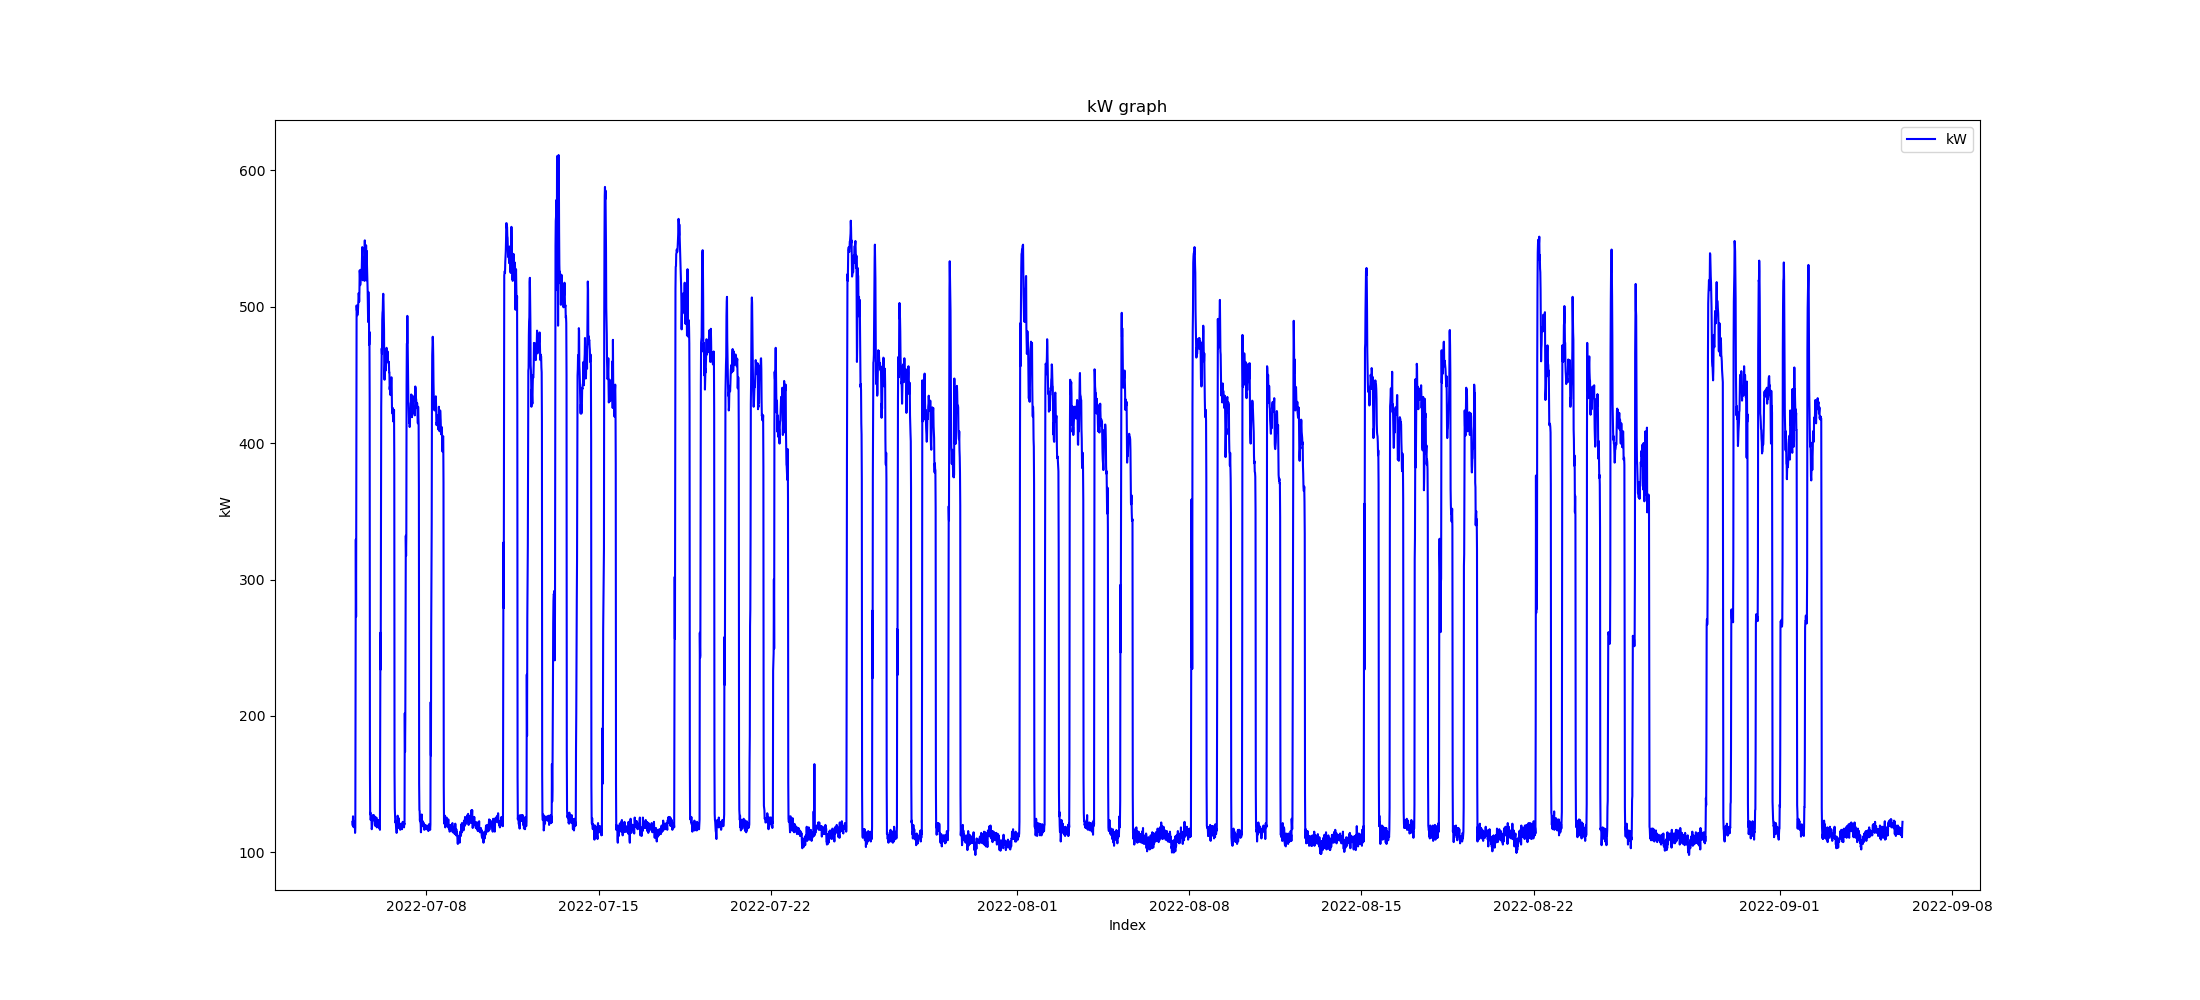

In [12]:
plt.figure(figsize=(22,10))

plt.plot(date_range_df2["kW"], label="kW", color="blue")

# Adding labels and title
plt.xlabel("Index")
plt.ylabel("kW")
plt.title("kW graph")

# Adding legend
plt.legend()

# Displaying the plot
plt.show()

In [13]:
X_with_holiday = date_range_df2.drop('kW', axis = 1)
y_with_holiday = date_range_df2.kW

X_with_holiday_scaled = scaler.transform(X_with_holiday)

y_pred_with_holiday = model.predict(X_with_holiday_scaled)

189/189 [==============================] - 1s 4ms/step


In [14]:
real_pred_combined = y_with_holiday.copy()

display(real_pred_combined)

real_pred_combined = pd.DataFrame(real_pred_combined)

display(real_pred_combined)

Date Time
2022-07-05 00:00:00    122.400
2022-07-05 00:15:00    119.700
2022-07-05 00:30:00    126.448
2022-07-05 00:45:00    118.800
2022-07-05 01:00:00    120.600
                        ...   
2022-09-05 22:45:00    112.500
2022-09-05 23:00:00    113.400
2022-09-05 23:15:00    111.152
2022-09-05 23:30:00    118.800
2022-09-05 23:45:00    122.400
Name: kW, Length: 6048, dtype: float64

,kW
Date Time,
2022-07-05 00:00:00,122.400
2022-07-05 00:15:00,119.700
2022-07-05 00:30:00,126.448
2022-07-05 00:45:00,118.800
2022-07-05 01:00:00,120.600
...,...
2022-09-05 22:45:00,112.500
2022-09-05 23:00:00,113.400
2022-09-05 23:15:00,111.152


In [15]:
real_pred_combined.rename(columns={'kW' : 'Real kW'}, inplace=True)
real_pred_combined['Predicted kW'] = y_pred_with_holiday

display(real_pred_combined)

,Real kW,Predicted kW
Date Time,,
2022-07-05 00:00:00,122.400,124.651970
2022-07-05 00:15:00,119.700,124.651970
2022-07-05 00:30:00,126.448,124.651970
2022-07-05 00:45:00,118.800,124.651970
2022-07-05 01:00:00,120.600,118.551880
...,...,...
2022-09-05 22:45:00,112.500,119.956070
2022-09-05 23:00:00,113.400,124.764618
2022-09-05 23:15:00,111.152,124.764618


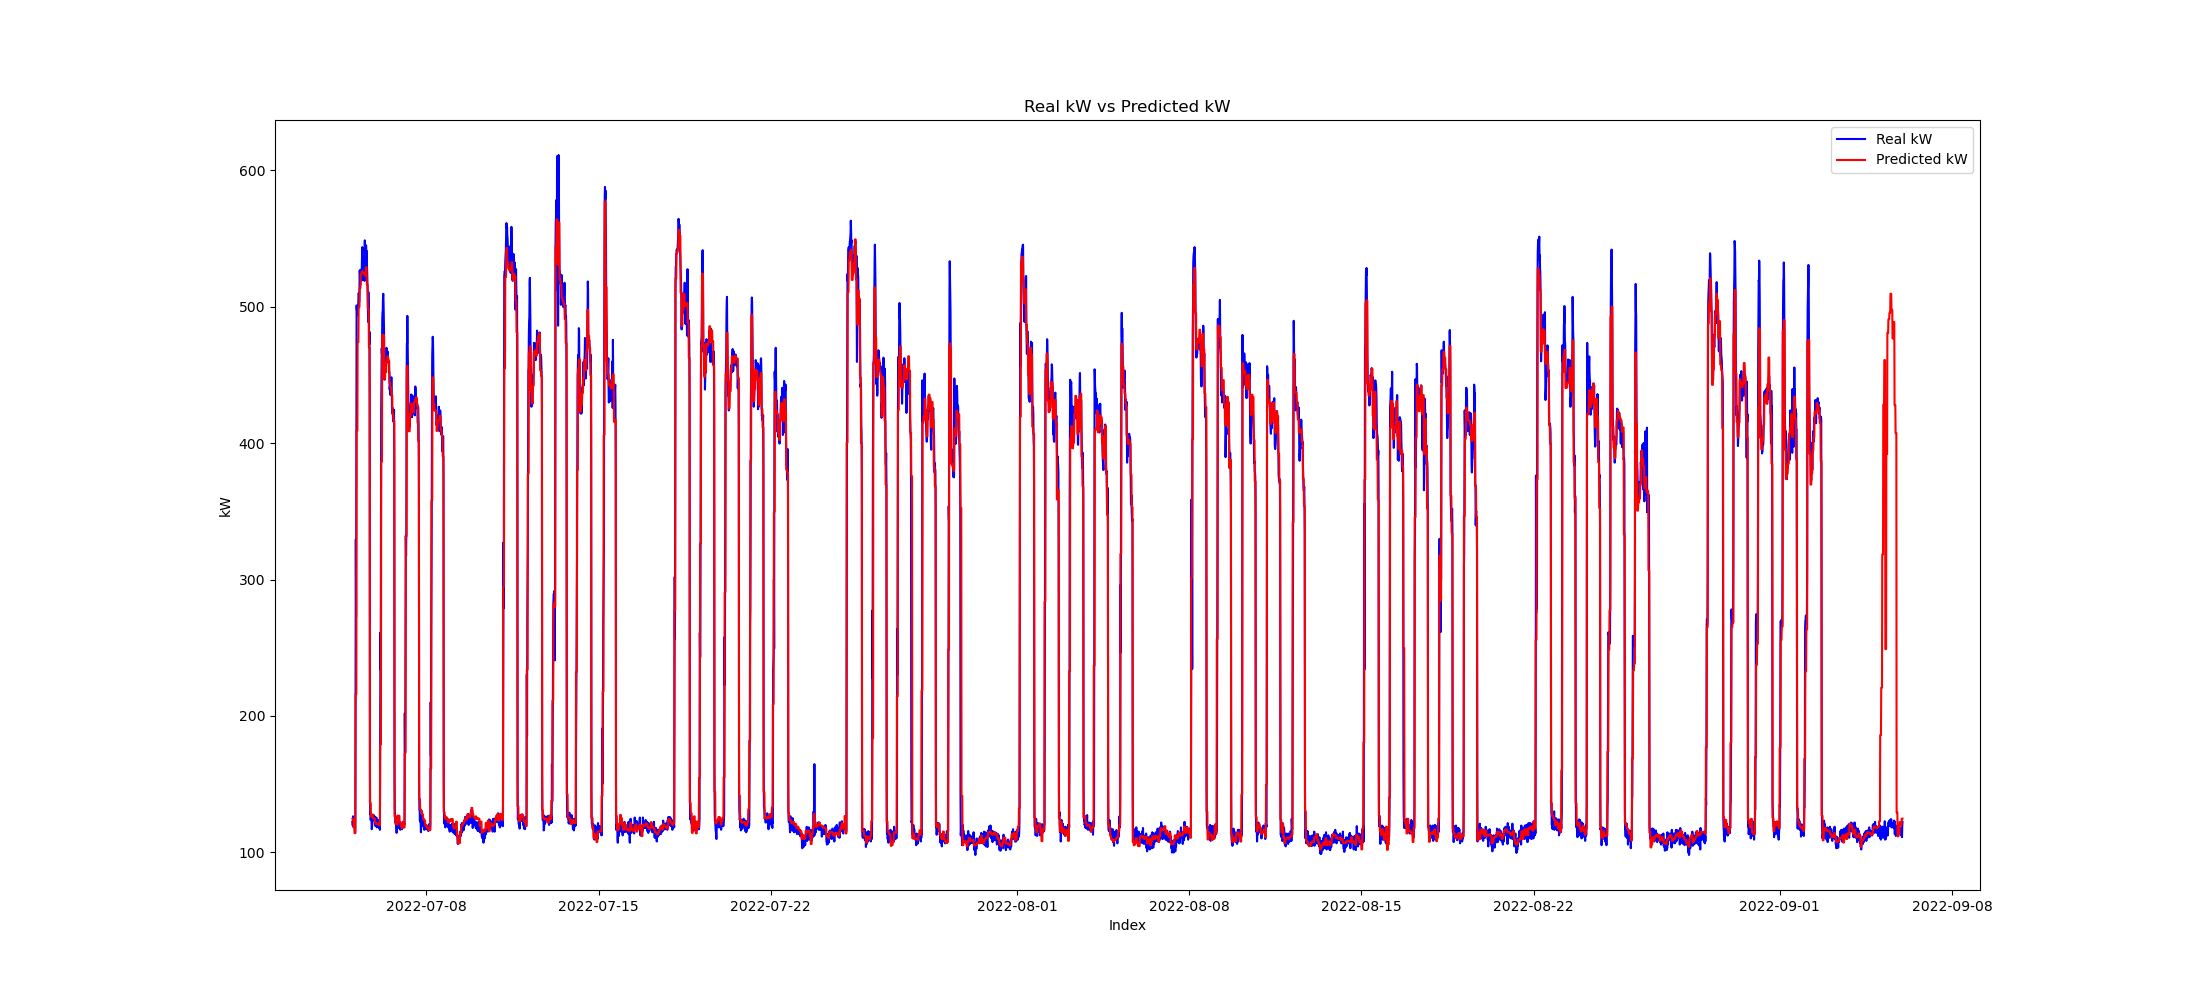

In [16]:
plt.figure(figsize=(22,10))

plt.plot(real_pred_combined["Real kW"], label="Real kW", color="blue")
plt.plot(real_pred_combined["Predicted kW"], label="Predicted kW", color="red")

# Adding labels and title
plt.xlabel("Index")
plt.ylabel("kW")
plt.title("Real kW vs Predicted kW")

# Adding legend
plt.legend()

# Displaying the plot
plt.show()

In [17]:
real_pred_combined.to_excel('holidays.xlsx', index=True)

In [18]:
display(df)

,kW,Nantum,Season,Altimeter reading,DP Temp (F),DB Temp (F),Heat_day,Cool_day,DP_12h,DB_12h,DP_24h,DB_24h,Weekday_0,Weekday_1,Weekday_2,Weekday_3,Weekday_4,Weekday_5,Weekday_6
Date Time,,,,,,,,,,,,,,,,,,,
2022-03-24 00:00:00,121.500,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,1,0,0,0
2022-03-24 00:15:00,121.500,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,1,0,0,0
2022-03-24 00:30:00,119.248,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,1,0,0,0
2022-03-24 00:45:00,120.600,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,1,0,0,0
2022-03-24 01:00:00,123.300,0,0,30.11,16.0,56,0.093750,0.000000,12.0,74.0,23.0,58.0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-22 22:45:00,117.448,1,0,30.03,34.0,49,0.166667,0.000000,26.0,57.0,38.0,46.0,0,0,1,0,0,0,0
2023-03-22 23:00:00,115.200,1,0,30.03,34.0,50,0.156250,0.000000,24.0,57.0,38.0,45.0,0,0,1,0,0,0,0
2023-03-22 23:15:00,118.348,1,0,30.03,34.0,50,0.156250,0.000000,24.0,57.0,38.0,45.0,0,0,1,0,0,0,0


In [19]:
start_date3 = '2022-05-30'
end_date3 = '2022-05-30'

one_day = df.loc[start_date3:end_date3]

display(one_day)

,kW,Nantum,Season,Altimeter reading,DP Temp (F),DB Temp (F),Heat_day,Cool_day,DP_12h,DB_12h,DP_24h,DB_24h,Weekday_0,Weekday_1,Weekday_2,Weekday_3,Weekday_4,Weekday_5,Weekday_6
Date Time,,,,,,,,,,,,,,,,,,,
2022-05-30 00:00:00,141.752,0,0,29.75,23.0,69,0.0,0.125000,5.0,88.0,38.0,73.0,1,0,0,0,0,0,0
2022-05-30 00:15:00,114.752,0,0,29.75,23.0,69,0.0,0.125000,5.0,88.0,38.0,73.0,1,0,0,0,0,0,0
2022-05-30 00:30:00,112.500,0,0,29.75,23.0,69,0.0,0.125000,5.0,88.0,38.0,73.0,1,0,0,0,0,0,0
2022-05-30 00:45:00,112.500,0,0,29.75,23.0,69,0.0,0.125000,5.0,88.0,38.0,73.0,1,0,0,0,0,0,0
2022-05-30 01:00:00,111.600,0,0,29.76,24.0,67,0.0,0.104167,5.0,87.0,37.0,73.0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-05-30 22:45:00,114.300,0,0,29.73,22.0,74,0.0,0.177083,22.0,75.0,7.0,73.0,1,0,0,0,0,0,0
2022-05-30 23:00:00,115.652,0,0,29.73,24.0,72,0.0,0.156250,23.0,77.0,7.0,72.0,1,0,0,0,0,0,0
2022-05-30 23:15:00,113.848,0,0,29.73,24.0,72,0.0,0.156250,23.0,77.0,7.0,72.0,1,0,0,0,0,0,0


In [20]:
X2 = date_range_df2.drop('kW', axis = 1)
y2 = date_range_df2.kW

#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

# Split data into training and temporary data (80% training, 20% temporary)
# X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)

# Split temporary data into testing and validation sets (50% testing, 50% validation)
# X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)


#Standardize features by removing the mean and scaling to unit variance
scaler2=StandardScaler()
scaler2.fit(X2)

X2_scaled = scaler2.transform(X2)

# X_val_scaled = scaler.transform(X_val)

In [21]:
epoch = 500

# Sequential constructor automatically/implicitly creates an input layer when the first layer is added to the model. Its shape is determined by the "input_dim" parameter of the first layer
model2 = Sequential()

# Dense layers (all connected) are added to the neural network with the specified neuron amount
# 128 neurons in the 1st hidden layer 
model2.add(Dense(128, input_dim=18, activation='relu'))

# 128 neurons in the 2nd hidden layer
model2.add(Dense(128, activation='tanh'))

# 128 neurons in the 2nd hidden layer
model2.add(Dense(128, activation='relu'))

# 128 neurons in the 2nd hidden layer
model2.add(Dense(128, activation='relu'))

# Output layer, linear activation function does nothing except adding the results of previous neurons together
model2.add(Dense(1, activation='linear'))

model2.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])
model2.summary()

# history = model.fit(X_train_scaled, y_train, validation_data=[X_val_scaled, y_val] , epochs = epoch)

history2 = model2.fit(X2_scaled, y2, epochs = epoch)


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_5 (Dense)             (None, 128)               2432      
                                                                 
 dense_6 (Dense)             (None, 128)               16512     
                                                                 
 dense_7 (Dense)             (None, 128)               16512     
                                                                 
 dense_8 (Dense)             (None, 128)               16512     
                                                                 
 dense_9 (Dense)             (None, 1)                 129       
                                                                 
Total params: 52097 (203.50 KB)
Trainable params: 52097 (203.50 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/500
189/

In [22]:
X_with_holiday2 = one_day.drop('kW', axis = 1)
y_with_holiday2 = one_day.kW

X_with_holiday_scaled2 = scaler2.transform(X_with_holiday2)

y_pred_with_holiday2 = model2.predict(X_with_holiday_scaled2)

3/3 [==============================] - 0s 874us/step


In [23]:
real_pred_combined2 = y_with_holiday2.copy()

display(real_pred_combined2)

real_pred_combined2 = pd.DataFrame(real_pred_combined2)

display(real_pred_combined2)

Date Time
2022-05-30 00:00:00    141.752
2022-05-30 00:15:00    114.752
2022-05-30 00:30:00    112.500
2022-05-30 00:45:00    112.500
2022-05-30 01:00:00    111.600
                        ...   
2022-05-30 22:45:00    114.300
2022-05-30 23:00:00    115.652
2022-05-30 23:15:00    113.848
2022-05-30 23:30:00    114.752
2022-05-30 23:45:00    111.152
Name: kW, Length: 96, dtype: float64

,kW
Date Time,
2022-05-30 00:00:00,141.752
2022-05-30 00:15:00,114.752
2022-05-30 00:30:00,112.500
2022-05-30 00:45:00,112.500
2022-05-30 01:00:00,111.600
...,...
2022-05-30 22:45:00,114.300
2022-05-30 23:00:00,115.652
2022-05-30 23:15:00,113.848


In [24]:
real_pred_combined2.rename(columns={'kW' : 'Real kW'}, inplace=True)
real_pred_combined2['Predicted kW'] = y_pred_with_holiday2

display(real_pred_combined2)

,Real kW,Predicted kW
Date Time,,
2022-05-30 00:00:00,141.752,117.122475
2022-05-30 00:15:00,114.752,117.122475
2022-05-30 00:30:00,112.500,117.122475
2022-05-30 00:45:00,112.500,117.122475
2022-05-30 01:00:00,111.600,157.498810
...,...,...
2022-05-30 22:45:00,114.300,133.001602
2022-05-30 23:00:00,115.652,228.381119
2022-05-30 23:15:00,113.848,228.381119


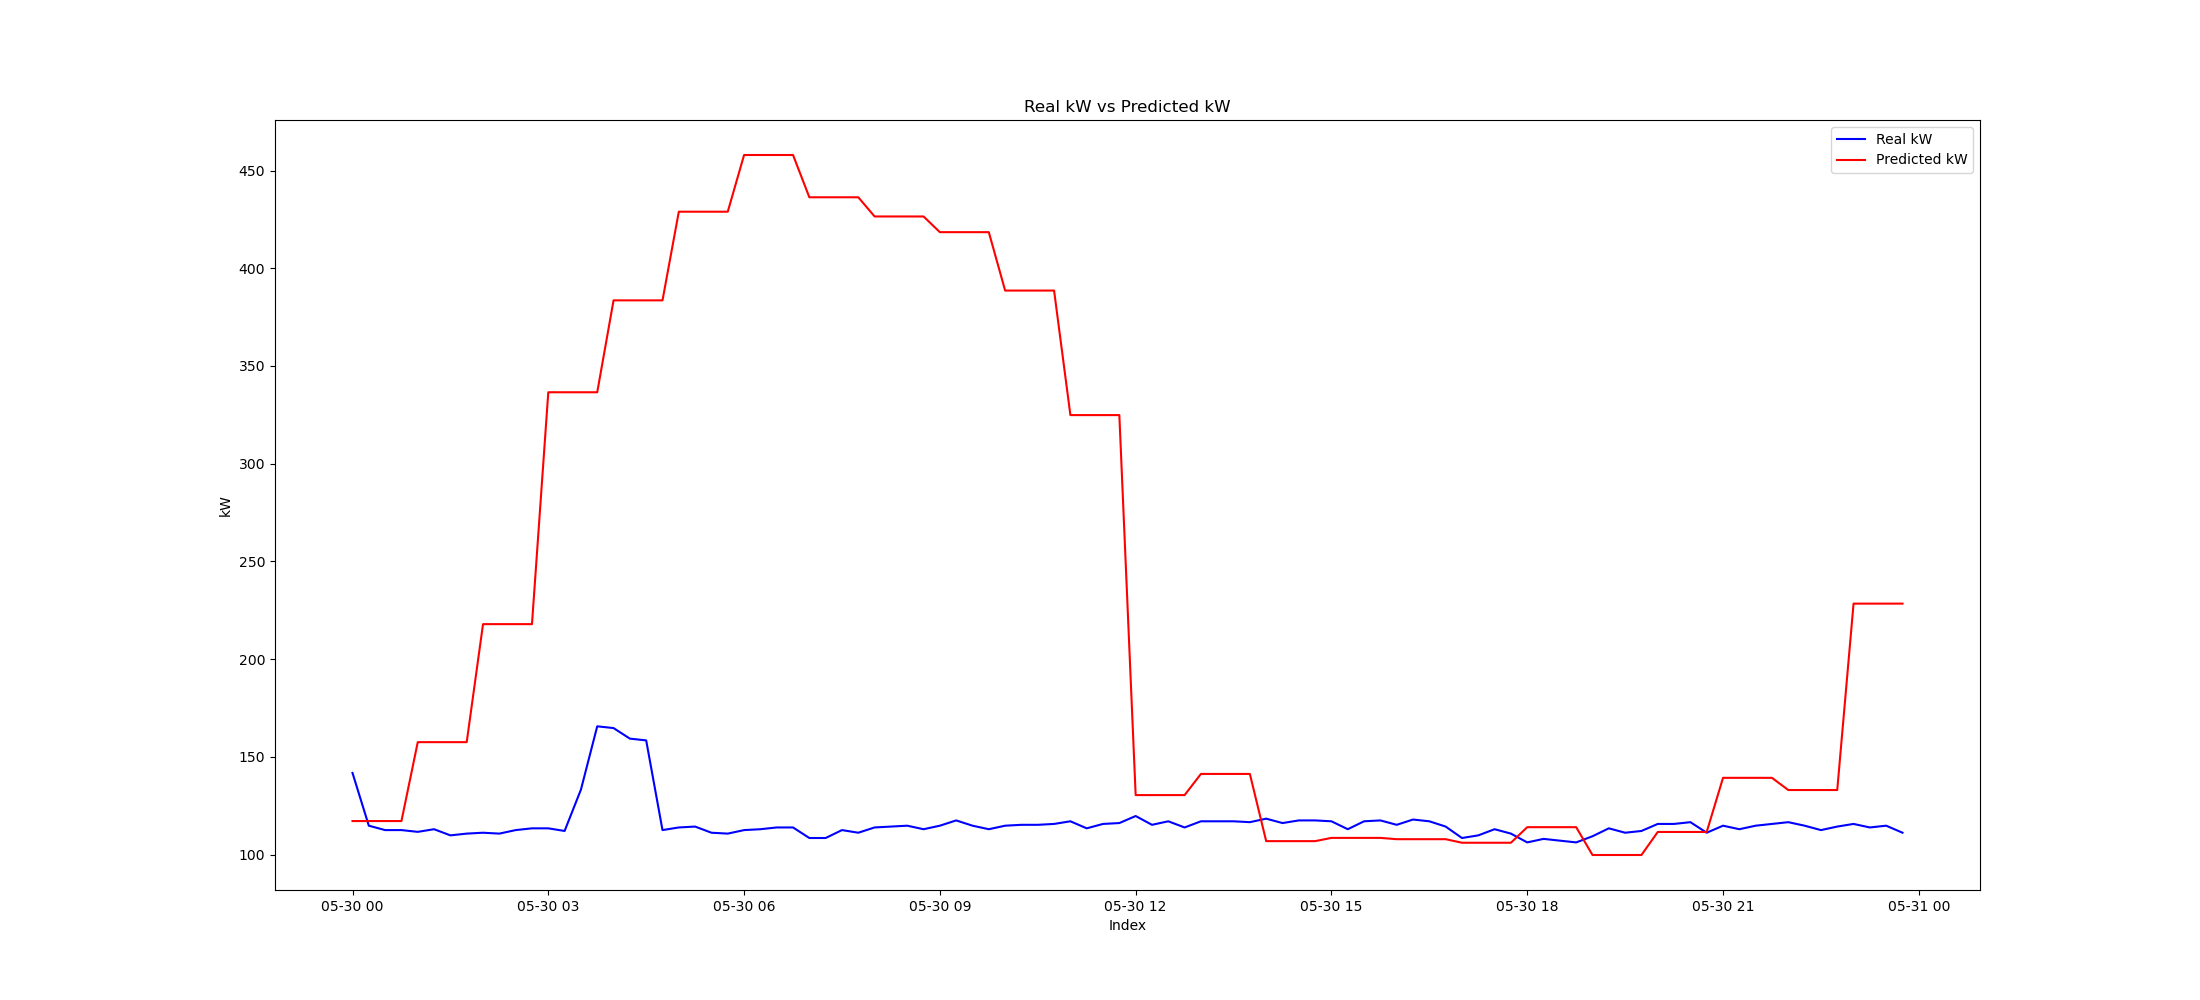

In [25]:
plt.figure(figsize=(22,10))

plt.plot(real_pred_combined2["Real kW"], label="Real kW", color="blue")
plt.plot(real_pred_combined2["Predicted kW"], label="Predicted kW", color="red")

# Adding labels and title
plt.xlabel("Index")
plt.ylabel("kW")
plt.title("Real kW vs Predicted kW")

# Adding legend
plt.legend()

# Displaying the plot
plt.show()